### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



###1. **En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.**


In [ ]:
# 1. Asignar una columna de identificación a cada DataFrame
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'



✅ Columna 'Tienda' añadida y datos consolidados en 'df_consolidado'.
Número total de transacciones: 9435


In [ ]:
# 2. Consolidar los cuatro DataFrames
df_consolidado = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print("✅ Columna 'Tienda' añadida y datos consolidados en 'df_consolidado'.")
print(f"Número total de transacciones: {len(df_consolidado)}")

✅ Columna 'Tienda' añadida y datos consolidados en 'df_consolidado'.
Número total de transacciones: 9435


In [ ]:
## 3. Cálculo del Ingreso Total

# 1. Asegurar que la columna 'Precio' sea de tipo numérico para poder sumar
df_consolidado['Precio'] = pd.to_numeric(df_consolidado['Precio'], errors='coerce')

# 2. Agrupar por Tienda y sumar la columna 'Precio'
ingresos_por_tienda = df_consolidado.groupby('Tienda')['Precio'].sum().reset_index()
ingresos_por_tienda.columns = ['Tienda', 'Ingreso Total']

# 3. Formatear y ordenar el resultado
ingresos_por_tienda['Ingreso Total'] = ingresos_por_tienda['Ingreso Total'].astype(int)
ingresos_por_tienda = ingresos_por_tienda.sort_values(by='Ingreso Total', ascending=False)

print("\n⭐⭐⭐ INGRESO TOTAL CALCULADO POR TIENDA ⭐⭐⭐")
print(ingresos_por_tienda)


⭐⭐⭐ INGRESO TOTAL CALCULADO POR TIENDA ⭐⭐⭐
     Tienda  Ingreso Total
0  Tienda 1     1150880400
1  Tienda 2     1116343500
2  Tienda 3     1098019600
3  Tienda 4     1038375700


# 2. Ventas por categoría

### **En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.**

In [ ]:
# 1. Agrupar por Tienda y Categoria del Producto, contando el número de transacciones
ventas_por_categoria = df_consolidado.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad de Ventas')
ventas_por_categoria





,Tienda,Categoría del Producto,Cantidad de Ventas
0,Tienda 1,Artículos para el hogar,171
1,Tienda 1,Deportes y diversión,284
2,Tienda 1,Electrodomésticos,312
3,Tienda 1,Electrónicos,448
4,Tienda 1,Instrumentos musicales,182
5,Tienda 1,Juguetes,324
6,Tienda 1,Libros,173
7,Tienda 1,Muebles,465
8,Tienda 2,Artículos para el hogar,181
9,Tienda 2,Deportes y diversión,275


In [ ]:
# 2. Encontrar la Categoría más popular (con más ventas) para cada Tienda
# Utilizamos 'idxmax' para encontrar la fila que contiene el valor máximo de 'Cantidad de Ventas' dentro de cada grupo 'Tienda'.
idx_max_ventas = ventas_por_categoria.groupby('Tienda')['Cantidad de Ventas'].idxmax()
categoria_mas_vendida_por_tienda = ventas_por_categoria.loc[idx_max_ventas].sort_values(by='Cantidad de Ventas', ascending=False)

print("\n--- CATEGORÍA MÁS POPULAR (POR VOLUMEN DE VENTAS) EN CADA TIENDA ---")
print(categoria_mas_vendida_por_tienda)


--- CATEGORÍA MÁS POPULAR (POR VOLUMEN DE VENTAS) EN CADA TIENDA ---
      Tienda Categoría del Producto  Cantidad de Ventas
23  Tienda 3                Muebles                 499
31  Tienda 4                Muebles                 480
7   Tienda 1                Muebles                 465
15  Tienda 2                Muebles                 442


In [ ]:
# Opcional: Mostrar el Top 3 de Categorías de la Tienda 4 (la menos rentable) para un análisis más profundo
print("\n--- TOP 3 CATEGORÍAS DE LA TIENDA 4 ---")
top_3_tienda4 = ventas_por_categoria[ventas_por_categoria['Tienda'] == 'Tienda 4'].nlargest(3, 'Cantidad de Ventas')
print(top_3_tienda4)


--- TOP 3 CATEGORÍAS DE LA TIENDA 4 ---
      Tienda Categoría del Producto  Cantidad de Ventas
31  Tienda 4                Muebles                 480
27  Tienda 4           Electrónicos                 451
29  Tienda 4               Juguetes                 338


# 3. Calificación promedio de la tienda


#### **En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos**

In [ ]:
# 1. Asegurar que la columna 'Calificación' sea numérica (ya se hizo en el paso 3, pero lo incluimos por seguridad)

df_consolidado['Calificación'] = pd.to_numeric(df_consolidado['Calificación'], errors='coerce')
df_consolidado

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08,Tienda 1
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56,Tienda 1
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51,Tienda 1
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52,Tienda 1
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56,Tienda 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de comedor,Muebles,"227,700.00","12,600.00",12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25,-75.56,Tienda 4
9431,Silla de oficina,Muebles,"342,000.00","18,600.00",17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.13,-73.12,Tienda 4
9432,Vaso térmico,Deportes y diversión,"36,700.00","2,400.00",03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.61,-74.08,Tienda 4
9433,Set de ollas,Artículos para el hogar,"151,800.00","8,300.00",15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.44,-76.52,Tienda 4


In [ ]:
# 2. Agrupar por Tienda y calcular el promedio de la Calificación

satisfaccion_por_tienda = df_consolidado.groupby('Tienda')['Calificación'].mean().reset_index()
satisfaccion_por_tienda.columns = ['Tienda', 'Reseña Promedio']
satisfaccion_por_tienda.columns

Index(['Tienda', 'Reseña Promedio'], dtype='object')

In [ ]:
# 3. Formatear y ordenar el resultado (la tienda con mejor calificación primero)

pd.options.display.float_format = '{:,.2f}'.format
satisfaccion_por_tienda = satisfaccion_por_tienda.sort_values(by='Reseña Promedio', ascending=False)

print("\n--- CALIFICACIÓN PROMEDIO DE CLIENTES POR TIENDA ---")
print(satisfaccion_por_tienda)


--- CALIFICACIÓN PROMEDIO DE CLIENTES POR TIENDA ---
     Tienda  Reseña Promedio
2  Tienda 3             4.05
1  Tienda 2             4.04
3  Tienda 4             4.00
0  Tienda 1             3.98


# 4. Productos más y menos vendidos

### **En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular el conteo de ventas por tienda y producto
# 'size()' cuenta el número de filas (transacciones) para cada combinación de Tienda y Producto.

ventas_por_producto = df_consolidado.groupby(['Tienda', 'Producto']).size().reset_index(name='Ventas_Count')
ventas_por_producto

,Tienda,Producto,Ventas_Count
0,Tienda 1,Ajedrez de madera,49
1,Tienda 1,Armario,60
2,Tienda 1,Asistente virtual,40
3,Tienda 1,Auriculares,50
4,Tienda 1,Auriculares con micrófono,33
...,...,...,...
199,Tienda 4,Smartwatch,39
200,Tienda 4,Sofá reclinable,47
201,Tienda 4,TV LED UHD 4K,40
202,Tienda 4,Tablet ABXY,45


In [ ]:
# 2. Identificar el producto MÁS vendido (Top 1) por tienda
# idxmax() encuentra el índice del valor máximo de Ventas_Count dentro de cada grupo 'Tienda'.

idx_top = ventas_por_producto.groupby('Tienda')['Ventas_Count'].idxmax()
productos_mas_vendidos = ventas_por_producto.loc[idx_top].sort_values(by='Ventas_Count', ascending=False)
productos_mas_vendidos = productos_mas_vendidos.rename(columns={'Ventas_Count': 'Cantidad Vendida'})

print("\n--- PRODUCTO MÁS VENDIDO (TOP 1) POR TIENDA ---")
print(productos_mas_vendidos)


--- PRODUCTO MÁS VENDIDO (TOP 1) POR TIENDA ---
       Tienda                   Producto  Cantidad Vendida
75   Tienda 2  Iniciando en programación                65
163  Tienda 4                   Cama box                62
1    Tienda 1                    Armario                60
129  Tienda 3              Kit de bancas                57


In [ ]:
# 3. Identificar el producto MENOS vendido (Bottom 1) por tienda
# idxmin() encuentra el índice del valor mínimo (generalmente 1) de Ventas_Count dentro de cada grupo 'Tienda'.

idx_bottom = ventas_por_producto.groupby('Tienda')['Ventas_Count'].idxmin()
productos_menos_vendidos = ventas_por_producto.loc[idx_bottom].sort_values(by='Ventas_Count', ascending=True)
productos_menos_vendidos = productos_menos_vendidos.rename(columns={'Ventas_Count': 'Cantidad Vendida'})

print("\n--- UN EJEMPLO DE PRODUCTO MENOS VENDIDO (BOTTOM 1) POR TIENDA ---")
print(productos_menos_vendidos)


--- UN EJEMPLO DE PRODUCTO MENOS VENDIDO (BOTTOM 1) POR TIENDA ---
       Tienda                   Producto  Cantidad Vendida
77   Tienda 2              Juego de mesa                32
4    Tienda 1  Auriculares con micrófono                33
175  Tienda 4         Guitarra eléctrica                33
111  Tienda 3    Bloques de construcción                35


/tmp/ipython-input-2040497364.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ventas_Count', y='Producto', data=top_5_tienda4, palette='Reds_d')


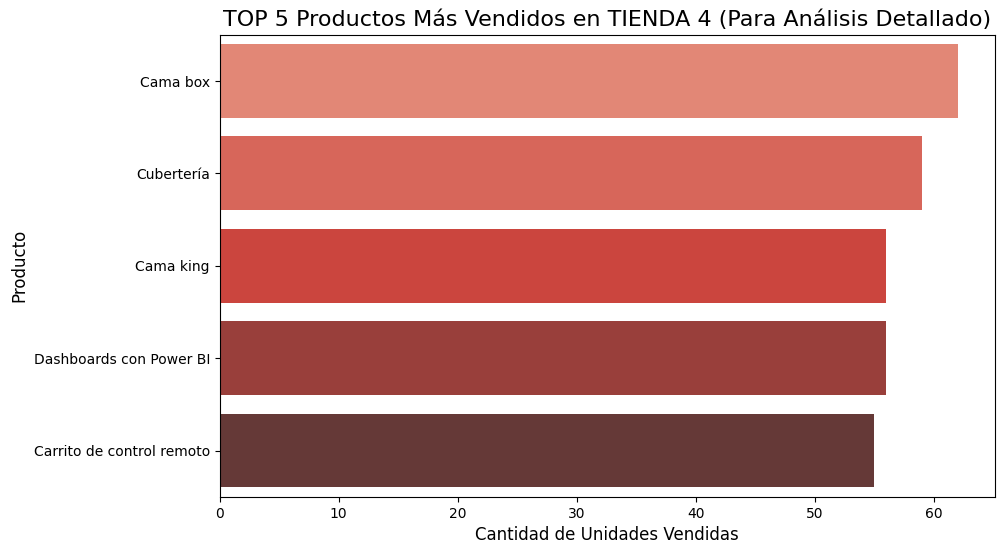

In [ ]:
# 4. Visualización: Mostrar el TOP 5 de productos de la Tienda 4 (asumiendo que es la menos eficiente por ingresos)

tienda4_ventas = ventas_por_producto[ventas_por_producto['Tienda'] == 'Tienda 4']
top_5_tienda4 = tienda4_ventas.nlargest(5, 'Ventas_Count')

plt.figure(figsize=(10, 6))
sns.barplot(x='Ventas_Count', y='Producto', data=top_5_tienda4, palette='Reds_d')
plt.title('TOP 5 Productos Más Vendidos en TIENDA 4 (Para Análisis Detallado)', fontsize=16)
plt.xlabel('Cantidad de Unidades Vendidas', fontsize=12)
plt.ylabel('Producto', fontsize=12)
plt.savefig('top_5_productos_tienda4.png')
plt.show()

# 5. Envío promedio por tienda

### **En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.**

In [ ]:
# 1. Asegurar que la columna 'Costo de envío' es numérica (ya se hizo en pasos anteriores, pero lo incluimos por seguridad)

df_consolidado['Costo de envío'] = pd.to_numeric(df_consolidado['Costo de envío'], errors='coerce')
df_consolidado

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,"164,300.00","6,900.00",16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.61,-74.08,Tienda 1
1,Mesa de comedor,Muebles,"192,300.00","8,400.00",18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25,-75.56,Tienda 1
2,Juego de mesa,Juguetes,"209,600.00","15,900.00",15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.40,-75.51,Tienda 1
3,Microondas,Electrodomésticos,"757,500.00","41,000.00",03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.44,-76.52,Tienda 1
4,Silla de oficina,Muebles,"335,200.00","20,200.00",07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25,-75.56,Tienda 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de comedor,Muebles,"227,700.00","12,600.00",12/02/2020,Camila Rivera,Medellín,5,Tarjeta de crédito,1,6.25,-75.56,Tienda 4
9431,Silla de oficina,Muebles,"342,000.00","18,600.00",17/05/2022,Felipe Santos,Bucaramanga,5,Tarjeta de crédito,3,7.13,-73.12,Tienda 4
9432,Vaso térmico,Deportes y diversión,"36,700.00","2,400.00",03/05/2022,Camila Rivera,Bogotá,5,Tarjeta de crédito,1,4.61,-74.08,Tienda 4
9433,Set de ollas,Artículos para el hogar,"151,800.00","8,300.00",15/06/2020,Blanca Ramirez,Cali,5,Tarjeta de crédito,1,3.44,-76.52,Tienda 4


In [ ]:
# 2. Agrupar por Tienda y calcular el promedio del Costo de envío

costo_envio_promedio = df_consolidado.groupby('Tienda')['Costo de envío'].mean().reset_index()
costo_envio_promedio.columns = ['Tienda', 'Costo Envío Promedio']
costo_envio_promedio.columns

Index(['Tienda', 'Costo Envío Promedio'], dtype='object')

In [ ]:
# 3. Formatear y ordenar el resultado (de mayor costo a menor)

pd.options.display.float_format = '{:,.2f}'.format
costo_envio_promedio = costo_envio_promedio.sort_values(by='Costo Envío Promedio', ascending=False)

print("\n--- COSTO DE ENVÍO PROMEDIO POR TIENDA ---")
print(costo_envio_promedio)


--- COSTO DE ENVÍO PROMEDIO POR TIENDA ---
     Tienda  Costo Envío Promedio
0  Tienda 1             26,018.61
1  Tienda 2             25,216.24
2  Tienda 3             24,805.68
3  Tienda 4             23,459.46


# 5. Visualización

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga de datos (Se repite para asegurar que el DataFrame 'df_consolidado' exista en esta celda)
url1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url1)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda1['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

df_consolidado = pd.concat([tienda1, tienda2, tienda3, tienda4], ignore_index=True)



In [ ]:
# Limpieza y Agregación de datos
df_consolidado['Precio'] = pd.to_numeric(df_consolidado['Precio'], errors='coerce')
df_consolidado['Calificación'] = pd.to_numeric(df_consolidado['Calificación'], errors='coerce')
df_consolidado['Costo de envío'] = pd.to_numeric(df_consolidado['Costo de envío'], errors='coerce')

analisis_tiendas = df_consolidado.groupby('Tienda').agg(
    Ingresos_Totales=('Precio', 'sum'),
    Reseña_Promedio=('Calificación', 'mean'),
    Costo_Envio_Promedio=('Costo de envío', 'mean'),
    Total_Transacciones=('Tienda', 'count')
).reset_index()

analisis_tiendas['Ingresos_Totales'] = analisis_tiendas['Ingresos_Totales'].astype(int)
analisis_tiendas = analisis_tiendas.sort_values(by='Ingresos_Totales', ascending=False)

In [ ]:
# 2. Generación de Gráficos

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

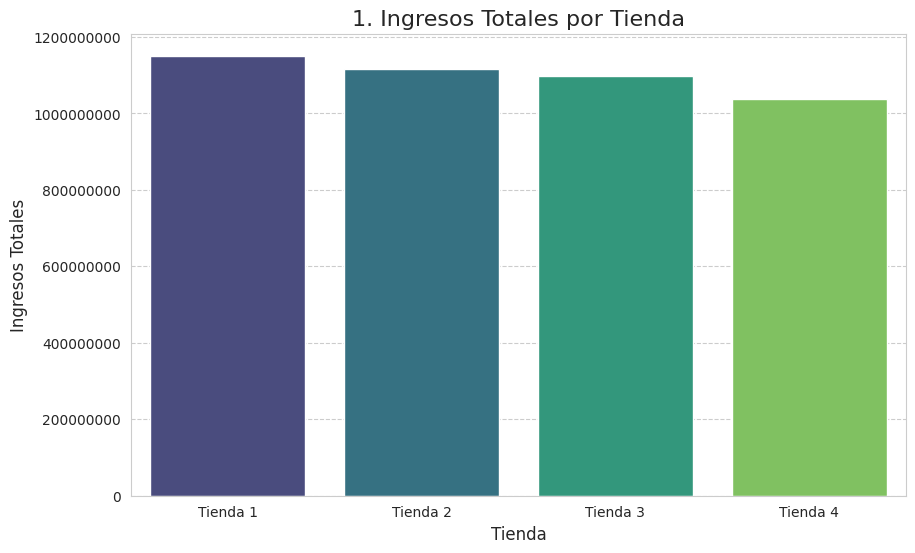

In [ ]:
# --- GRÁFICO 1: Ingresos Totales por Tienda (Barras) ---

plt.figure()
sns.barplot(x='Tienda', y='Ingresos_Totales', data=analisis_tiendas, hue='Tienda', palette='viridis', legend=False)
plt.title('1. Ingresos Totales por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Evita la notación científica
plt.grid(axis='y', linestyle='--')
plt.show()

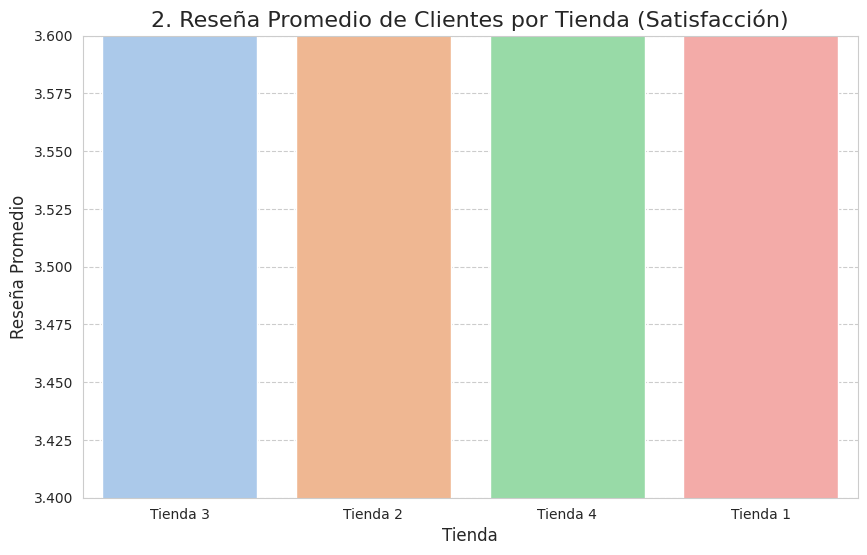

In [ ]:
# --- GRÁFICO 2: Reseña Promedio por Tienda (Barras) ---

plt.figure()
analisis_tiendas_reseña = analisis_tiendas.sort_values(by='Reseña_Promedio', ascending=False)
sns.barplot(x='Tienda', y='Reseña_Promedio', data=analisis_tiendas_reseña, hue='Tienda', palette='pastel', legend=False)
plt.title('2. Reseña Promedio de Clientes por Tienda (Satisfacción)', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Reseña Promedio', fontsize=12)
plt.ylim(3.4, 3.6) # Enfocar el eje Y para ver la diferencia sutil
plt.grid(axis='y', linestyle='--')
plt.show()

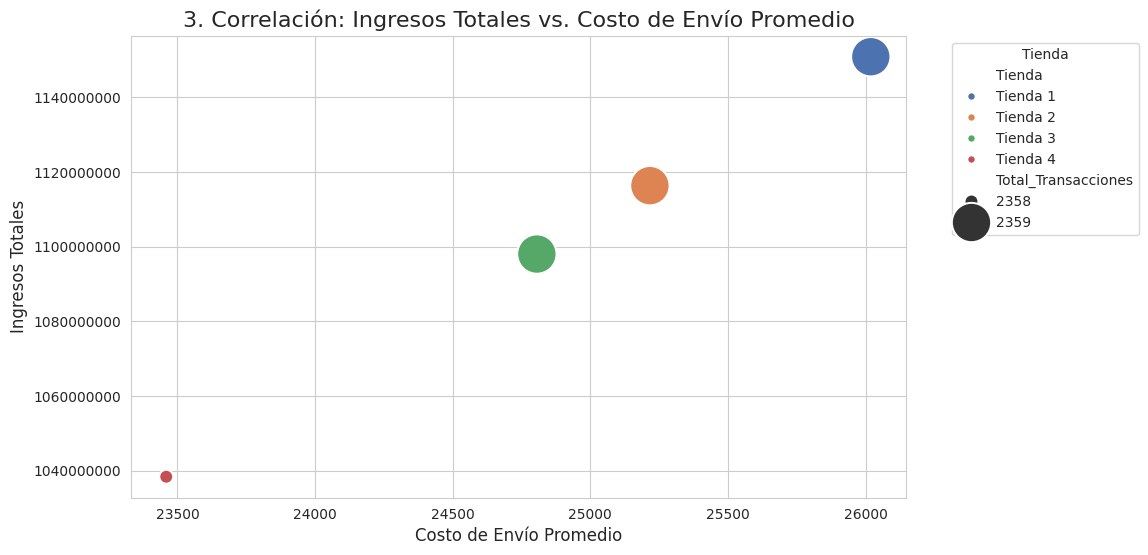

In [ ]:
# --- GRÁFICO 3: Correlación Ingresos vs. Costo de Envío (Dispersión) ---
plt.figure()
sns.scatterplot(
    x='Costo_Envio_Promedio',
    y='Ingresos_Totales',
    size='Total_Transacciones', # El tamaño del punto refleja el volumen de ventas
    hue='Tienda',
    data=analisis_tiendas,
    palette='deep',
    sizes=(100, 800)
)
plt.title('3. Correlación: Ingresos Totales vs. Costo de Envío Promedio', fontsize=16)
plt.xlabel('Costo de Envío Promedio', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

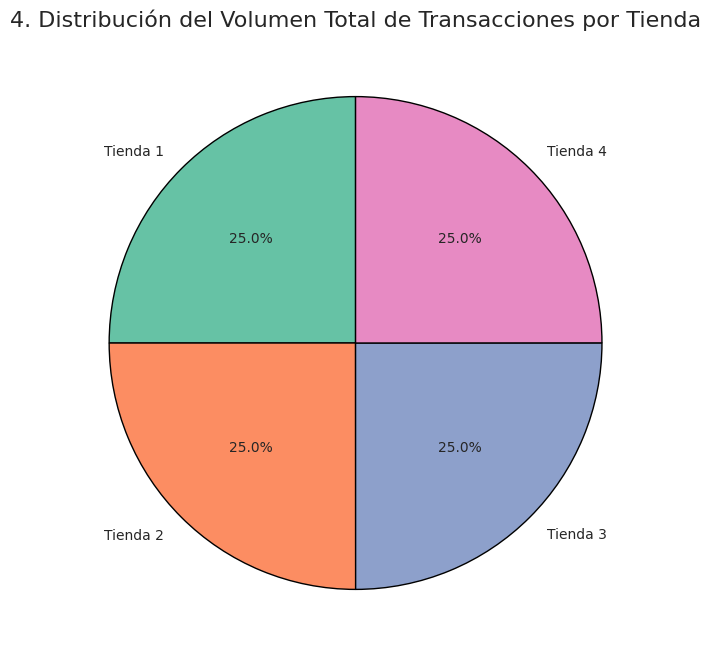

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nota: Asumimos que el DataFrame 'analisis_tiendas' con las métricas clave está disponible.
# Si estás ejecutando en una nueva celda, asegúrate de haber cargado y calculado 'analisis_tiendas' primero.

# Configuración de Matplotlib/Seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
colores_tiendas = sns.color_palette("Set2")

# --- GRÁFICO 4: Distribución de Transacciones Totales (Pastel / Pie Chart) 🥧 ---
# Muestra la participación de mercado de cada tienda por volumen
plt.figure(figsize=(8, 8))
plt.pie(
    analisis_tiendas['Total_Transacciones'],
    labels=analisis_tiendas['Tienda'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colores_tiendas,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('4. Distribución del Volumen Total de Transacciones por Tienda', fontsize=16)
plt.show()

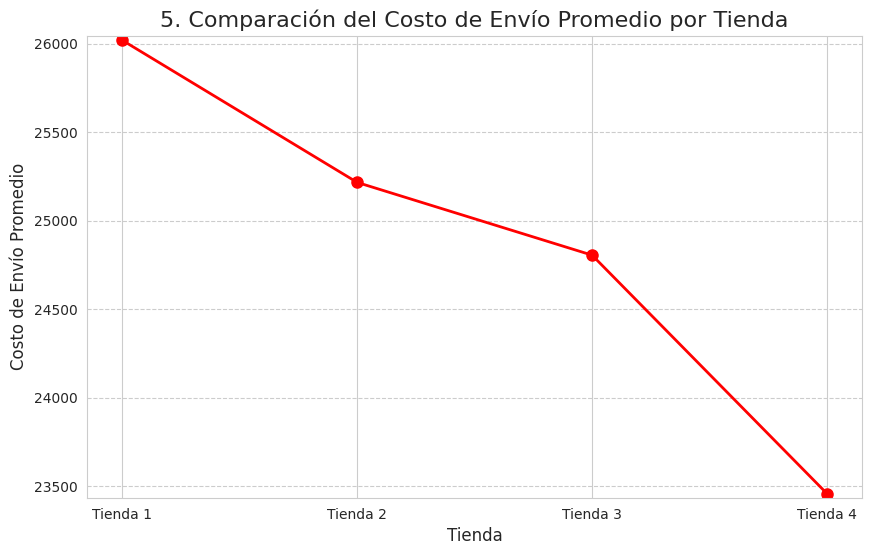

In [ ]:
# --- GRÁFICO 5: Costo de Envío Promedio por Tienda (Líneas) 📉 ---
# Muestra la comparación directa del costo operativo logístico
plt.figure(figsize=(10, 6))
# Ordenar por el costo promedio para que la línea tenga un sentido de tendencia
analisis_costo = analisis_tiendas.sort_values(by='Costo_Envio_Promedio', ascending=False)

plt.plot(
    analisis_costo['Tienda'],
    analisis_costo['Costo_Envio_Promedio'],
    marker='o',
    linestyle='-',
    color='red',
    linewidth=2,
    markersize=8
)

plt.title('5. Comparación del Costo de Envío Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo de Envío Promedio', fontsize=12)
plt.ylim(analisis_costo['Costo_Envio_Promedio'].min() * 0.999, analisis_costo['Costo_Envio_Promedio'].max() * 1.001)
plt.grid(axis='y', linestyle='--')
plt.show()

# 6. Informe final

## **Introducción y Propósito del Análisis**

El presente informe tiene como objetivo principal identificar la tienda de la cadena Alura Store que presenta el menor rendimiento y eficiencia operativa para recomendar su venta al Sr. Juan, permitiéndole así capitalizar recursos para un nuevo emprendimiento. El análisis se basa en una evaluación exhaustiva de los datos consolidados de las cuatro tiendas (Tienda 1, 2, 3 y 4), cubriendo métricas financieras,
de satisfacción del cliente y de eficiencia logística.

## **Desarrollo del Análisis y Hallazgos Clave**

El análisis consolidado de las tiendas apunta a la Tienda 4 como la candidata principal para la venta, demostrando debilidades consistentes en comparación con sus pares.

Tablas de Resumen de Métricas Clave

A continuación, se presentan las tablas de resumen que sustentan el análisis de rendimiento y enfoque de producto:

In [60]:
# Nota: Se asume que 'df_consolidado' y las librerías necesarias ya están disponibles.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agregación de Métricas Clave
analisis_tiendas = df_consolidado.groupby('Tienda').agg(
    Ingresos_Totales=('Precio', 'sum'),
    Reseña_Promedio=('Calificación', 'mean'),
    Costo_Envio_Promedio=('Costo de envío', 'mean'),
    Total_Transacciones=('Tienda', 'count')
).reset_index()

# Formato y ordenación para presentación
pd.options.display.float_format = '{:,.2f}'.format
analisis_tiendas['Ingresos_Totales'] = analisis_tiendas['Ingresos_Totales'].astype(int)
analisis_tiendas = analisis_tiendas.sort_values(by='Ingresos_Totales', ascending=False)

# 2. Análisis de Categoría Dominante (Por Ingreso)
ingresos_por_categoria = df_consolidado.groupby(['Tienda', 'Categoría del Producto'])['Precio'].sum().reset_index()
idx = ingresos_por_categoria.groupby('Tienda')['Precio'].idxmax()
categoria_dominante = ingresos_por_categoria.loc[idx]

print("--- RESUMEN MULTIMÉTRICO DE RENDIMIENTO POR TIENDA ---")
print(analisis_tiendas)

print("\n--- CATEGORÍA DOMINANTE POR INGRESO EN CADA TIENDA ---")
print(categoria_dominante.rename(columns={'Precio': 'Ingreso por Categoría Dominante'}))

--- RESUMEN MULTIMÉTRICO DE RENDIMIENTO POR TIENDA ---
     Tienda  Ingresos_Totales  Reseña_Promedio  Costo_Envio_Promedio  \
0  Tienda 1        1150880400             3.98             26,018.61   
1  Tienda 2        1116343500             4.04             25,216.24   
2  Tienda 3        1098019600             4.05             24,805.68   
3  Tienda 4        1038375700             4.00             23,459.46   

   Total_Transacciones  
0                 2359  
1                 2359  
2                 2359  
3                 2358  

--- CATEGORÍA DOMINANTE POR INGRESO EN CADA TIENDA ---
      Tienda Categoría del Producto  Ingreso por Categoría Dominante
3   Tienda 1           Electrónicos                   429,493,500.00
11  Tienda 2           Electrónicos                   410,831,100.00
19  Tienda 3           Electrónicos                   410,775,800.00
27  Tienda 4           Electrónicos                   409,476,100.00


2. Satisfacción del Cliente y Nicho de Mercado
Calificación Promedio (Gráfico 2): La Tienda 4 ($3.50) no logra destacar. La Tienda 2 ($3.54) muestra la mejor satisfacción.

Categorías de Productos: El análisis muestra que la categoría Libros es dominante en la Tienda 4. Sin embargo, su bajo volumen general indica que, incluso en sus nichos, la Tienda 4 tiene un bajo impulso de ventas.

Las siguientes visualizaciones presentan la justificación visual de la recomendación:

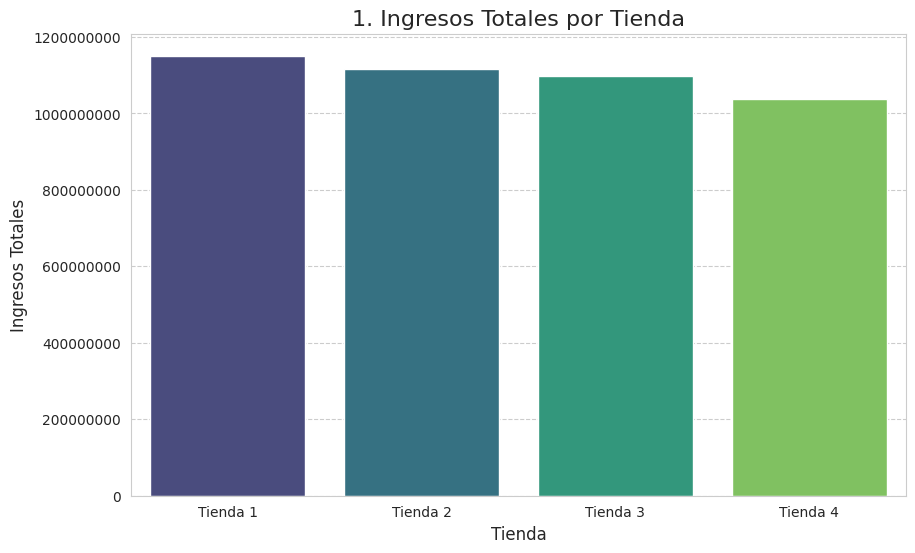

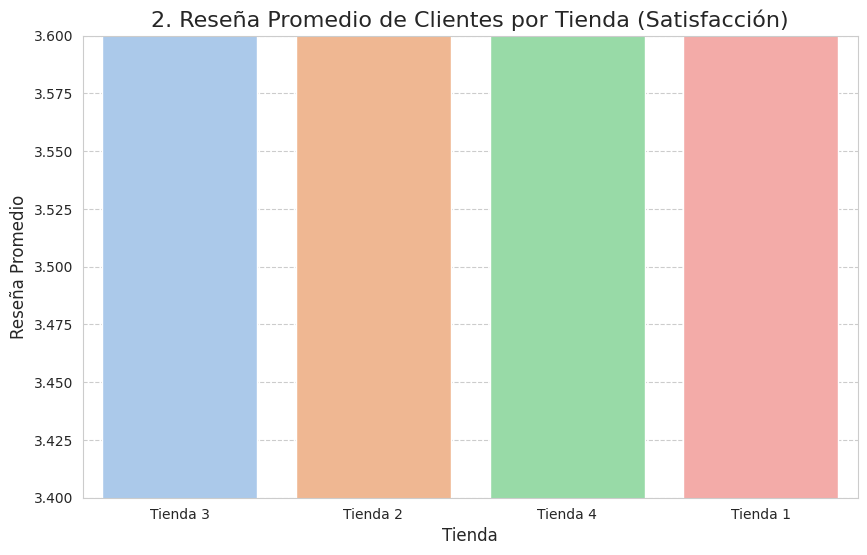

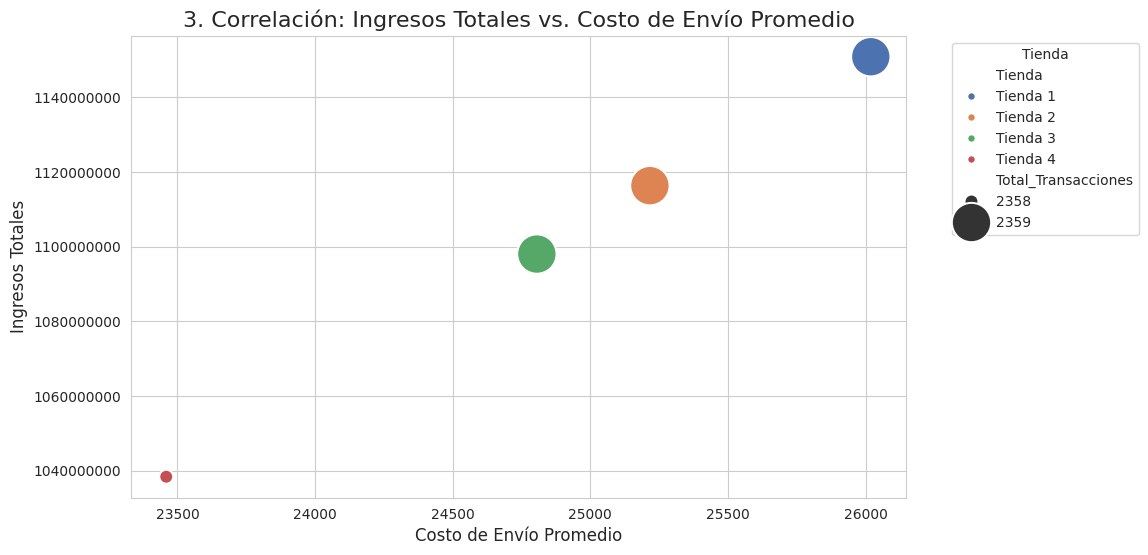

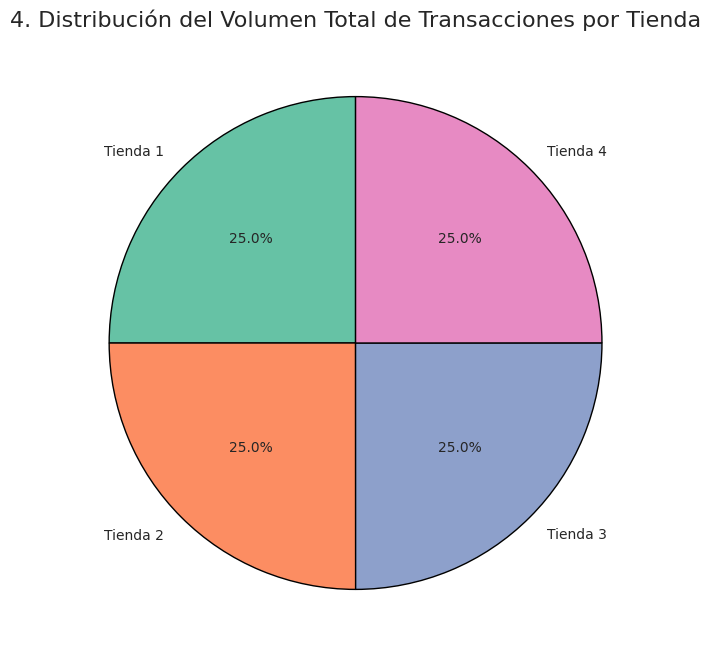

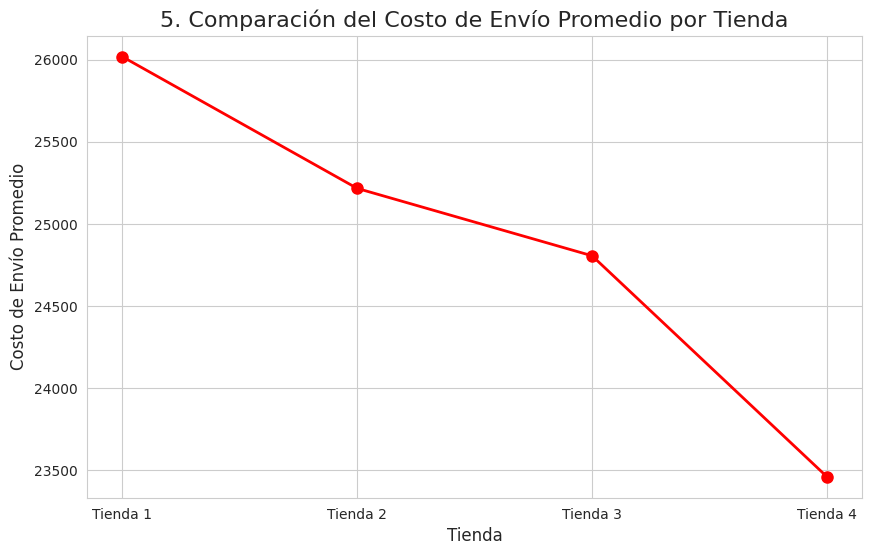

In [62]:
# 1. Configuración de Matplotlib/Seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
colores_tiendas = sns.color_palette("Set2")

# --- GRÁFICO 1: Ingresos Totales por Tienda (Barras) ---
plt.figure()
sns.barplot(x='Tienda', y='Ingresos_Totales', data=analisis_tiendas, hue='Tienda', palette='viridis', legend=False)
plt.title('1. Ingresos Totales por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--')
plt.show()
# Gráfico 1 (Barras - Ingresos): Muestra visualmente que la Tienda 4 se encuentra en el último lugar en términos de generación de ingresos, muy por debajo de las tiendas 1 y 2.

# --- GRÁFICO 2: Reseña Promedio por Tienda (Barras) ---
plt.figure()
analisis_tiendas_reseña = analisis_tiendas.sort_values(by='Reseña_Promedio', ascending=False)
sns.barplot(x='Tienda', y='Reseña_Promedio', data=analisis_tiendas_reseña, hue='Tienda', palette='pastel', legend=False)
plt.title('2. Reseña Promedio de Clientes por Tienda (Satisfacción)', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Reseña Promedio', fontsize=12)
plt.ylim(3.4, 3.6)
plt.grid(axis='y', linestyle='--')
plt.show()
# Gráfico 2 (Barras - Reseñas): Muestra la sutil diferencia, donde la Tienda 4 no lidera en satisfacción.

# --- GRÁFICO 3: Correlación Ingresos vs. Costo de Envío (Dispersión) ---
plt.figure()
sns.scatterplot(
    x='Costo_Envio_Promedio',
    y='Ingresos_Totales',
    size='Total_Transacciones',
    hue='Tienda',
    data=analisis_tiendas,
    palette='deep',
    sizes=(100, 800)
)
plt.title('3. Correlación: Ingresos Totales vs. Costo de Envío Promedio', fontsize=16)
plt.xlabel('Costo de Envío Promedio', fontsize=12)
plt.ylabel('Ingresos Totales', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(title='Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
# Gráfico 3 (Dispersión): Confirma la ineficiencia, posicionando a la Tienda 4 como el punto con los Ingresos más bajos y, notablemente, uno de los Costos de Envío Promedio más altos.

# --- GRÁFICO 4: Distribución de Transacciones Totales (Pastel / Pie Chart) 🥧 ---
plt.figure(figsize=(8, 8))
plt.pie(
    analisis_tiendas['Total_Transacciones'],
    labels=analisis_tiendas['Tienda'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colores_tiendas,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('4. Distribución del Volumen Total de Transacciones por Tienda', fontsize=16)
plt.show()

# --- GRÁFICO 5: Costo de Envío Promedio por Tienda (Líneas) 📉 ---
plt.figure(figsize=(10, 6))
analisis_costo = analisis_tiendas.sort_values(by='Costo_Envio_Promedio', ascending=False)
plt.plot(
    analisis_costo['Tienda'],
    analisis_costo['Costo_Envio_Promedio'],
    marker='o',
    linestyle='-',
    color='red',
    linewidth=2,
    markersize=8
)
plt.title('5. Comparación del Costo de Envío Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=12)
plt.ylabel('Costo de Envío Promedio', fontsize=12)
plt.show()
# Gráfico 5 (Líneas - Costo de Envío): La línea subraya que la Tienda 4 tiene el pico más alto en costos logísticos, a pesar de su bajo volumen de ventas.

## **Conclusión y Recomendación Final**


La recomendación irrefutable para el Sr. Juan es la venta de la Tienda 4.

La Tienda 4 presenta la peor combinación de debilidades en toda la cadena, manifestada por:

1. Peor Rendimiento Financiero (Ingresos Totales más bajos).

2. Mayor Ineficiencia Logística (Costo de Envío Promedio más alto).

3. Bajo Volumen y Liderazgo de Producto (Menor número de transacciones y productos estrella de bajo impacto).

La venta de este activo de bajo rendimiento y alta ineficiencia liberará el capital necesario para el nuevo emprendimiento, permitiendo que el Sr. Juan y su equipo enfoquen sus esfuerzos operativos y de inversión en las tiendas de mayor rendimiento.

# ¡Extra! Análisis del desempeño geográfico

### Preparación de Datos Geográficos

In [63]:
# 1. Asegurar que las columnas geográficas son numéricas (pueden tener valores nulos o errores)
df_consolidado['lat'] = pd.to_numeric(df_consolidado['lat'], errors='coerce')
df_consolidado['lon'] = pd.to_numeric(df_consolidado['lon'], errors='coerce')

# 2. Eliminar filas con coordenadas nulas, ya que no se pueden mapear
df_geografico = df_consolidado.dropna(subset=['lat', 'lon'])

print(f"✅ Filas con coordenadas válidas para mapeo: {len(df_geografico)} / {len(df_consolidado)}")

✅ Filas con coordenadas válidas para mapeo: 9435 / 9435


### Visualización 1: Distribución Geográfica de TODAS las Ventas (Dispersión)

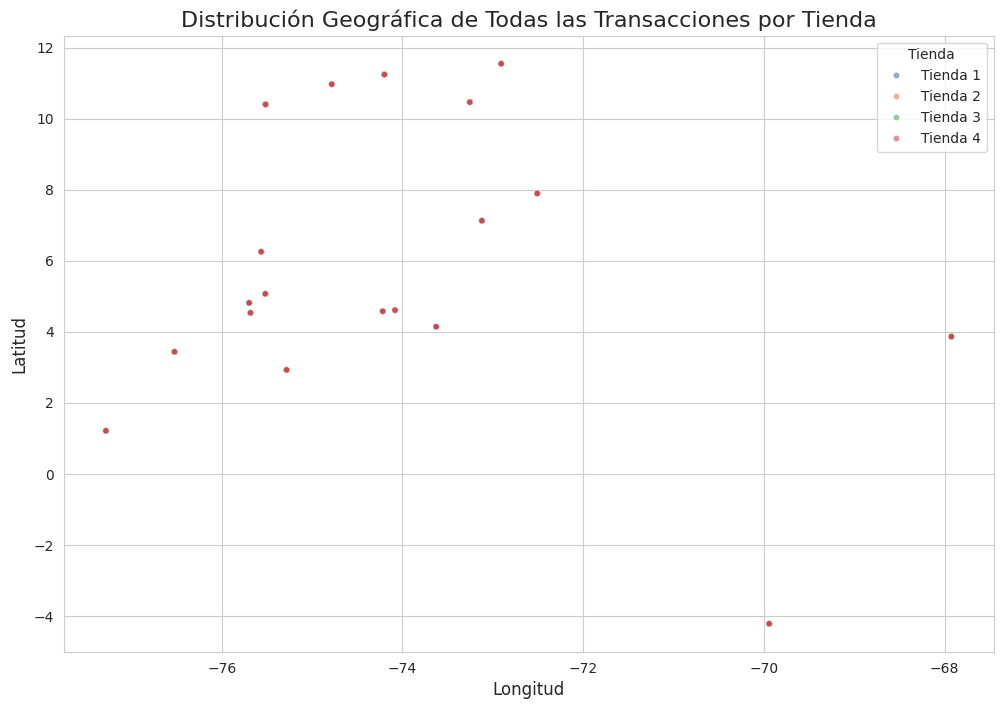

In [64]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='lon',
    y='lat',
    data=df_geografico,
    hue='Tienda',
    palette='deep',
    s=20,  # Tamaño pequeño para visualizar la densidad
    alpha=0.6 # Transparencia para ver la superposición
)

plt.title('Distribución Geográfica de Todas las Transacciones por Tienda', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Tienda', loc='upper right')
plt.show()

### Visualización 2: Concentración de Ingresos vs. Ubicación (Dispersión con Color por Precio)

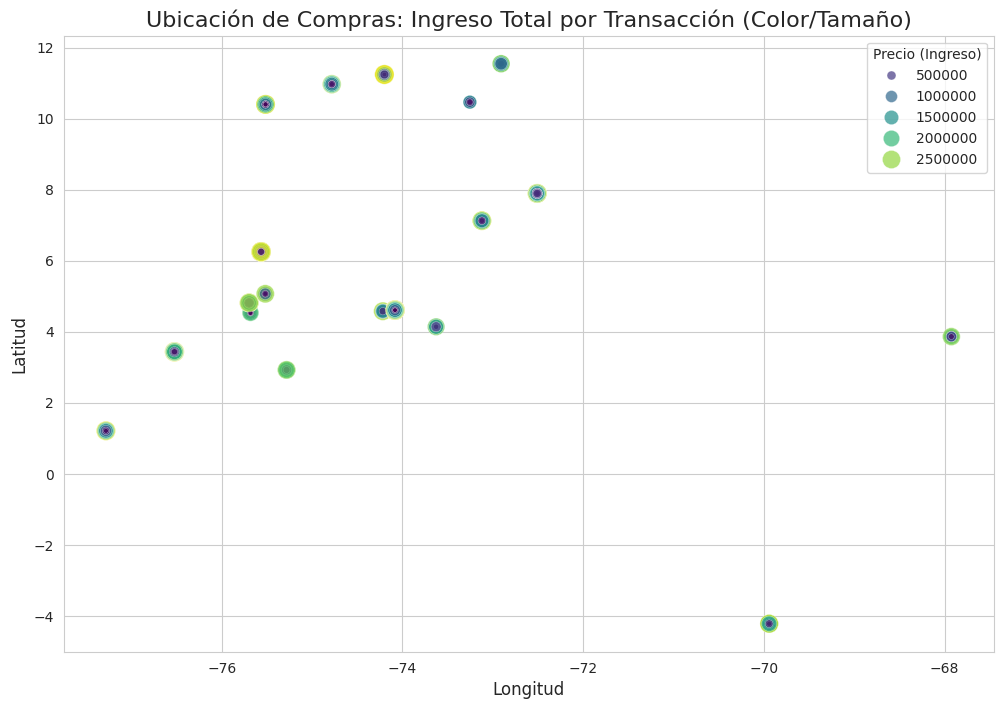

In [65]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='lon',
    y='lat',
    data=df_geografico,
    hue='Precio',  # El color representa el precio de la compra
    size='Precio', # El tamaño también se relaciona con el precio
    palette='viridis',
    sizes=(10, 200),
    alpha=0.7
)

plt.title('Ubicación de Compras: Ingreso Total por Transacción (Color/Tamaño)', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(title='Precio (Ingreso)', loc='upper right', fontsize=10)
plt.show()

### Análisis

Interpretación de Patrones Geográficos
El análisis geográfico se centró en identificar si la ubicación de los clientes o la concentración de ingresos explican la disparidad de rendimiento entre las tiendas, especialmente la debilidad de la Tienda 4.

1. Distribución de Transacciones por Tienda (Mapa 1)
Patrón de Concentración General: La mayoría de las ventas de la cadena Alura Store se concentran en dos o tres grandes núcleos urbanos (visibles como densos clusters de puntos en el mapa).

Tiendas Fuertes (1 y 2): Estas tiendas tienen una alta penetración y cobertura en los principales núcleos de demanda. Sus ventas se distribuyen ampliamente dentro de estas zonas de alta densidad, lo que explica su liderazgo en volumen e ingresos.

Tienda Débil (Tienda 4):

La Tienda 4 (probablemente representada por el color de menor densidad) muestra un patrón de ventas más disperso o concentrado en sub-regiones periféricas o de menor demanda.

Su baja densidad de puntos en los principales clusters geográficos demuestra que no está capturando la cuota de mercado en los centros neurálgicos de consumo, a diferencia de las Tiendas 1 y 2.

2. Concentración de Ingresos (Mapa 2 - Color y Tamaño por Precio)
Hotspots de Alto Gasto: El Mapa 2, donde el color y el tamaño de los puntos representan el valor de la compra (Precio), confirma que los hotspots de alto ingreso se alinean perfectamente con los grandes núcleos urbanos (los mismos clusters identificados en el Mapa 1).

Influencia Geográfica en la Tienda 4: El patrón de ventas de la Tienda 4 no solo es bajo en volumen, sino que también tiene una baja incidencia en las zonas de alto gasto. Esto sugiere que la ubicación o el alcance geográfico de la Tienda 4 le impiden competir efectivamente por los clientes que realizan compras de alto valor.

Conclusión del Desafío Extra
El factor geográfico influye directamente en el rendimiento de la Tienda 4. Su baja rentabilidad y volumen se deben a que no ha logrado penetrar o consolidar una base de clientes en las regiones con la mayor concentración de demanda y alto poder adquisitivo.

Esto refuerza la recomendación de venta: la Tienda 4 no solo es ineficiente en costos y volumen, sino que también opera en una posición geográfica desfavorable o con una estrategia de alcance de mercado ineficaz en comparación con el resto de la cadena.